# Homework: Learning Audio Representations with Self-Supervision

In this homework, we will consolidate the knowledge gained during the seminar and further explore methods for self-supervised learning of audio representations.
During the seminar, we implemented and trained a model based on contrastive learning (InfoNCE). Now, we will extend this work by implementing non-contrastive learning (NCL) approaches and comparing them with previously studied methods.

We will examine how different training paradigms — supervised, contrastive, and non-contrastive — affect the quality of learned embeddings and the stability of the training process


## Multi-Format Contrastive Learning of Audio Representations(Paper from seminar)

The core idea of this approach is to learn robust audio embeddings by contrasting
different *formats* (or views) of the same audio sample.  
For example, one branch may encode the **raw waveform (1D)** while another encodes
its **spectrogram (2D)**.  

By applying a contrastive loss (InfoNCE), the model is trained to:
- **Pull together** embeddings from different formats of the same audio,
- **Push apart** embeddings from different audio samples.  

This multi-format setup encourages the encoder to capture **shared semantic content**
across input representations, leading to more general and transferable audio features.

[paper1](https://arxiv.org/pdf/2103.06508), [paper2](https://arxiv.org/pdf/2010.09542)

[github source](https://github.com/HondamunigePrasannaSilva/CLAR?tab=readme-ov-file)

## AudioSet

Dataset with 10 numbers pronounced
```
!git clone https://github.com/soerenab/AudioMNIST.git
```



In [ ]:
!git clone https://github.com/soerenab/AudioMNIST.git

Cloning into 'AudioMNIST'...
remote: Enumerating objects: 30137, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 30137 (delta 9), reused 4 (delta 1), pack-reused 30119 (from 1)
Receiving objects: 100% (30137/30137), 944.54 MiB | 23.92 MiB/s, done.
Resolving deltas: 100% (35/35), done.
Updating files: 100% (30018/30018), done.


In [ ]:
!mkdir models

In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import random
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
from IPython.display import Audio
from pathlib import Path
from omegaconf import DictConfig

import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from tqdm.notebook import tqdm
from torch.utils.data import Subset, DataLoader
from torchaudio import transforms
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings("ignore", module="torchaudio._backend")

plt.rcParams.update({'font.size': 14})
random.seed(42)

In [ ]:
root = 'AudioMNIST/data'
rand_speaker = random.choice(os.listdir(root))
rand_audio = random.choice(os.listdir(os.path.join(root, rand_speaker)))
print(f'Speaker #{rand_speaker}, class #{rand_audio[0]}')

waveform, sample_rate = torchaudio.load(
    os.path.join(root, rand_speaker, rand_audio), normalize=True
)
print(f'Sample rate: {sample_rate}, waveform shape: {waveform.shape}')

Speaker #29, class #3
Sample rate: 48000, waveform shape: torch.Size([1, 36454])


In [ ]:
new_sample_rate = 16000
resample = T.Resample(orig_freq=sample_rate, new_freq=new_sample_rate)
resampled_waveform = resample(waveform)
Audio(resampled_waveform, rate=new_sample_rate)

## DataSet

In [ ]:
class AudioMNISTDataset(torch.utils.data.Dataset):
  def __init__(self, root, sr=16000):
    self.root = root
    self.sr = sr
    self.items = self.list_wavs_and_labels(root)

  def __len__(self):
    return len(self.items)

  def list_wavs_and_labels(self, root: str):
    base = Path(root)
    speakers = sorted([p for p in base.iterdir() if p.is_dir()])
    items = []
    for sp in speakers:
      for wav in sorted(sp.glob("**/*.wav")):
        # filename e.g., "9_10_0_0_1.wav" (digit_speaker_..)
        name = wav.stem.split("_")
        digit = int(name[0])
        speaker_id = sp.name
        items.append((str(wav), digit, speaker_id))
    return items

  def load_wav(self, path):
    wav, sr = torchaudio.load(path)  # [C, T]
    if sr != self.sr:
      wav = torchaudio.functional.resample(wav, sr, self.sr)
    wav = wav.mean(dim=0, keepdim=True)  # mono [1, T]
    return wav

  def __getitem__(self, idx):
    path, label, speaker = self.items[idx]
    wav = self.load_wav(path)
    return wav, label

def collate(batch):
  wavs, labels = zip(*batch)
  wavs = nn.utils.rnn.pad_sequence([w.squeeze(0).t() for w in wavs], batch_first=True)  # [B, Tw, 1]? we transposed; fix:
  wavs = nn.utils.rnn.pad_sequence([w.squeeze(0) for w in wavs], batch_first=True)  # [B, T]
  labels = torch.tensor(labels, dtype=torch.long)
  return wavs, labels

# Ensure data loading correctly
_test_ds = AudioMNISTDataset(root=root)
_test_ds[0]

(tensor([[0.0003, 0.0005, 0.0004,  ..., 0.0005, 0.0005, 0.0006]]), 0)

### Data split
Разделение на обучающую и тестовую чать даатсета. Всего 60 спикеров, из них 12 в тестовой части датасета.

In [ ]:
def split_indices_by_speaker(dataset: AudioMNISTDataset, test_speakers: set):
  train_idxs = []
  test_idxs = []
  for idx, (_, _, spk) in enumerate(dataset.items):
    if spk in test_speakers:
      test_idxs.append(idx)
    else:
      train_idxs.append(idx)
  return train_idxs, test_idxs

# Split dataset by speakers
NUM_TEST_SPEAKERS = 12
full_ds = AudioMNISTDataset(root=root)
all_speakers = sorted({spk for (_, _, spk) in full_ds.items})
valid_speakers = set(all_speakers[-NUM_TEST_SPEAKERS:])
train_idxs, valid_idxs = split_indices_by_speaker(full_ds, valid_speakers)
train_ds = Subset(full_ds, train_idxs)
valid_ds = Subset(full_ds, valid_idxs)

## Базовые модели

In [ ]:
class block(nn.Module):
  def __init__(self, in_channels, out_channels, identity_downsample=None, stride=1):
    super(block, self).__init__()

    self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
    self.bn1 = nn.BatchNorm1d(out_channels)

    self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
    self.bn2 = nn.BatchNorm1d(out_channels)

    self.identity_downsample = identity_downsample
    self.relu = nn.ReLU()

  def forward(self, x):
    identity = x

    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)

    x = self.conv2(x)
    x = self.bn2(x)

    if self.identity_downsample is not None:
        identity = self.identity_downsample(identity)

    x += identity
    x = self.relu(x)

    return x

class ResNet1D(nn.Module):
  def __init__(self, block, num_classes=10):
    super(ResNet1D, self).__init__()
    layers = [2, 2, 2, 2]
    self.expansion = 1

    self.in_channels = 64
    self.conv1 = nn.Conv1d(1, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
    self.bn1 = nn.BatchNorm1d(self.in_channels)
    self.relu = nn.ReLU()
    self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)

    self.layer1 = self._make_layer(block, 64, layers[0], stride=1)
    self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
    self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
    self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

    self.avgpool = nn.AdaptiveAvgPool1d((1))
    self.fc = nn.Linear(512 * self.expansion, num_classes)

  def _make_layer(self, block, out_channels, num_blocks, stride):
    identity_downsample = None
    if stride != 1 or self.in_channels != out_channels:
        identity_downsample = nn.Sequential(
            nn.Conv1d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
            nn.BatchNorm1d(out_channels)
        )

    layers = []
    layers.append(block(self.in_channels, out_channels, identity_downsample, stride))
    self.in_channels = out_channels

    for i in range(1, num_blocks):
        layers.append(block(self.in_channels, out_channels))

    return nn.Sequential(*layers)

  def forward(self, x, return_features=False):
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.maxpool(x)

    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    x = self.layer4(x)

    x = self.avgpool(x)
    if return_features:
      return x

    x = x.view(x.size(0), -1)
    x = self.fc(x)

    return x

In [ ]:
class block2D(nn.Module):
  def __init__(self, in_channels, out_channels, identity_downsample=None, stride=1):
    super(block2D, self).__init__()

    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
    self.bn1 = nn.BatchNorm2d(out_channels)

    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
    self.bn2 = nn.BatchNorm2d(out_channels)

    self.identity_downsample = identity_downsample
    self.relu = nn.ReLU()

  def forward(self, x):
    identity = x

    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)

    x = self.conv2(x)
    x = self.bn2(x)

    if self.identity_downsample is not None:
      identity = self.identity_downsample(identity)

    x += identity
    x = self.relu(x)

    return x

class ResNet2D(nn.Module):
  def __init__(self, block, num_classes=10, ):
    super(ResNet2D, self).__init__()
    layers = [2, 2, 2, 2]
    self.expansion = 1

    self.in_channels = 64
    self.conv1 = nn.Conv2d(1, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
    self.bn1 = nn.BatchNorm2d(self.in_channels)
    self.relu = nn.ReLU()
    self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

    self.layer1 = self._make_layer(block, 64, layers[0], stride=1)
    self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
    self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
    self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

    self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
    self.fc = nn.Linear(512 * self.expansion, num_classes)

  def _make_layer(self, block, out_channels, num_blocks, stride):
    identity_downsample = None
    if stride != 1 or self.in_channels != out_channels:
      _conv = nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False)
      _bn = nn.BatchNorm2d(out_channels)
      identity_downsample = nn.Sequential(_conv, _bn)

    layers = []
    layers.append(block(self.in_channels, out_channels, identity_downsample, stride))
    self.in_channels = out_channels

    for i in range(1, num_blocks):
      layers.append(block(self.in_channels, out_channels))

    return nn.Sequential(*layers)

  def forward(self, x, return_features=False):
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.maxpool(x)

    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    x = self.layer4(x)

    x = self.avgpool(x)
    if return_features:
      return x

    x = x.view(x.size(0), -1)
    x = self.fc(x)

    return x

### Аугментации

In [ ]:
def pitchshift(audio, SAMPLE_RATE=16000, shift = 2):
    """
    Pitch Shift (PS): randomly raises or lowers the pitch of the audio signal.\n
    Based on experimental observation,we found the range of pitch shifts that main-tained\n
    the overall coherency of the input audio was in the range [-15, 15] semitones.

    Attributes:
    - :param audio: audio tensor
    - :param SAMPLE_RATE: Sample rate, default=16000
    - :param shift: Pitch shift
    - :return: describe what it returns
    """
    assert audio != None, "audio should not be None"
    transform = transforms.PitchShift(sample_rate=SAMPLE_RATE, n_steps=shift)
    waveform_shift = transform(audio)
    return waveform_shift


def fade_in_out(audio):
    """
    Fade in/out (FD): gradually increases/decreases the intensity of the audio in the\n
    beginning/end of the audio signal.\n
    The degree of the fade was either linear, logarithmic or exponential (applied\n
    with uniform probability of 1/3). The size of the fade for either side of the\n
    audio signal could at maximum reach half of the audio signal. The size of the\n
    fade was another random parameter picked for each sample.
    """
    assert audio != None, "audio should not be None"
    _fade_shape = ['linear', 'logarithmic', 'exponential']
    _fade_size = [i for i in range(1, int(audio.shape[2]/2))]

    transform = transforms.Fade(fade_in_len=random.choice(_fade_size), fade_out_len=random.choice(_fade_size), fade_shape=random.choice(_fade_shape))
    waveform_fade_in_out = transform(audio)
    return waveform_fade_in_out

def add_white_noise_(signal, noise_level):
    """
    Noise Injection: mix the audio signal with random white, brown and pink noise.\n
    In our implementation, the intensity of the noise signal was randomly selected based\n
    on the strength of signal-to-noise ratio. Applied white, brown, or pink depending\n
    on an additional random parameter sampled from uniform distribution (Mixed Noise).
    """
    noise = torch.randn_like(signal)*torch.std(signal) * noise_level
    noisy_signal = signal + noise
    return noisy_signal


def timemasking(waveform, batch_size, sample_rate=16000):
    """
    Time masking:given an audio signal, in this transformation we randomly select a small\n
    segment of the full signal and set the signal values in that segment to normal noise or a\n
    constant value. In our implementation, we not only randomly selected the location of the\n
    masked segment but also we randomly selected the size of the segment. The size of the \n
    masked segment was set to maximally be 1/8 of the input signal.
    """
    """max_mask = int(sample_rate/8)*torch.ones(size=[batch_size])
    pos_iniziale = torch.randint(low=0, high=sample_rate, size=[batch_size])
    min_mask = sample_rate-pos_iniziale
    min_elements = torch.min(min_mask,max_mask)
    pos_finale = pos_iniziale+min_elements.to(torch.int)
    indices = torch.arange(sample_rate).unsqueeze(0).expand(batch_size, -1)
    range_mask = (indices >= pos_iniziale.unsqueeze(1)) & (indices <= pos_finale.unsqueeze(1))
    range_mask = range_mask[:,None,:]
    signal_[range_mask] = 0

    return signal_"""
    bs, ch, length = waveform.shape
    mask_len = length // 8
    augmented = waveform.clone()
    for i in range(bs):
        start = random.randint(0, length - mask_len)
        augmented[i, :, start:start + mask_len] = 0.0
    return augmented

def timeStretching():
    """
    slows down or speeds up the audio sample (while keeping the pitch unchanged).
    In this approach we transformed the signal by first computing the STFT of the signal, stretching
    it using a phase vocoder, and computing the inverse STFT to reconstruct the time domain signal.
    Following those transformations, we down-sampled or cropped the signal to match the same number
    of samples as the input signal. When the rate of stretching was greater than 1, the signal was
    sped up. Otherwise when the rate of stretching was less than 1, then the signal was slowed down.
    The rate of time stretching was randomized for each audio with range values of [0.5, 1.5].
    """
    return

In [ ]:
def createModelInput(audio, mel_transform, stft_trasform=None, augmentation=True, device=None):
  audio = audio.unsqueeze(1)
  # CALCUALTE AUGMENTATION 1 AND AUGMENTATION 2
  if augmentation == True:
    audio = fade_in_out(audio)
    audio = timemasking(audio, audio.shape[0])
    audio = audio.to(device)

  # Create the augmented spectograms size [BATCH_SIZE, 3, 200, 200]
  #spectograms = createSpectograms(audio, stft_trasform, mel_transform)
  spectograms = mel_transform(audio)
  spectograms = spectograms.to(device)
  return spectograms, audio

In [ ]:
class LogMelSpectrogram(T.MelSpectrogram):
  def __init__(self, eps=1e-8, **kwargs):
    super().__init__(**kwargs)
    self.eps = eps

  def forward(self, waveform):
    return (super().forward(waveform) + self.eps).log()

In [ ]:
#check for cuda
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Available device:", device)

Available device: cuda


## Task 1(2 points)

Impelment strightforward classifier training based on waveforms or spectrogram(use models from seminar). Train it in supervised manner and compute accuracy

### Тренировка базовых моделей

In [ ]:
def create_supervised_model(config, use_spectrogram=False, device=None):
  """Create supervised classification model"""
  if use_spectrogram:
    model = ResNet2D(block2D, num_classes=config.CLASSES).to(device)
  else:
    model = ResNet1D(block, num_classes=config.CLASSES).to(device)

  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(
      model.parameters(),
      lr=config.LR,
      betas=(config.B1, config.B2),
      weight_decay=config.WEIGHT_DECAY
  )
  return model, criterion, optimizer

In [ ]:
def train_supervised(model, criterion, optimizer, trainloader, valloader,
                     config, mel_transform, device, use_spectrogram=False):
    """Train model in supervised manner"""
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []

    for epoch in range(config.EPOCHS):
        # Training
        model.train()
        progress_bar = tqdm(total=len(trainloader), unit='step', desc=f'Epoch {epoch+1}/{config.EPOCHS}')
        epoch_losses = []
        epoch_correct = 0
        epoch_total = 0

        for audio, labels in trainloader:
            optimizer.zero_grad()

            audio = audio.to(device)
            labels = labels.to(device)

            # Подготовка входных данных
            spectrograms, audio_input = createModelInput(
                audio,
                mel_transform,
                None,
                augmentation=False,
                device=device
            )

            if use_spectrogram:
                outputs = model(spectrograms)
            else:
                outputs = model(audio_input)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

            # Считаем точность
            _, predicted = torch.max(outputs.data, 1)
            epoch_total += labels.size(0)
            epoch_correct += (predicted == labels).sum().item()

            progress_bar.update(1)

        train_losses.append(np.mean(epoch_losses))
        train_accs.append(epoch_correct / epoch_total)

        # Validation
        model.eval()
        val_losses_epoch = []
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for audio, labels in valloader:
                audio = audio.to(device)
                labels = labels.to(device)

                spectrograms, audio_input = createModelInput(
                    audio,
                    mel_transform,
                    None,
                    augmentation=False,
                    device=device
                )

                if use_spectrogram:
                    outputs = model(spectrograms)
                else:
                    outputs = model(audio_input)

                loss = criterion(outputs, labels)
                val_losses_epoch.append(loss.item())

                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_losses.append(np.mean(val_losses_epoch))
        val_accs.append(val_correct / val_total)

        progress_bar.set_postfix({
            'train_loss': f'{train_losses[-1]:.4f}',
            'train_acc': f'{train_accs[-1]:.4f}',
            'val_loss': f'{val_losses[-1]:.4f}',
            'val_acc': f'{val_accs[-1]:.4f}'
        })
        progress_bar.close()

    return train_losses, train_accs, val_losses, val_accs

In [ ]:
def evaluate(model, dataloader, criterion, mel_transform, use_spectrogram=False, device=None):
  """Evaluate model on validation set"""
  model.eval()
  total_loss = 0
  total_correct = 0
  total_samples = 0

  with torch.no_grad():
    for audio, labels in dataloader:
      audio = audio.to(device)
      labels = labels.to(device)

      spectrograms, audio_input = createModelInput(
          audio,
          mel_transform,
          None,
          augmentation=False,
          device=device
      )

      if use_spectrogram:
        outputs = model(spectrograms)
      else:
        outputs = model(audio_input)

      loss = criterion(outputs, labels)
      total_loss += loss.item()

      _, predicted = torch.max(outputs.data, 1)
      total_correct += (predicted == labels).sum().item()
      total_samples += labels.size(0)

  accuracy = total_correct / total_samples
  avg_loss = total_loss / len(dataloader)

  return accuracy, avg_loss

In [ ]:
# Configuration
hyperparameters = {
    'LR': 3e-4,
    'WEIGHT_DECAY': 1e-6,
    'B1': 0.9,
    'B2': 0.999,
    'EPOCHS': 10,
    'BATCH_SIZE': 64,
    'IMG_CHANNEL': 1,
    'CLASSES': 10,
    'EVAL_BATCH': 128,
    'EVAL_EPOCHS': 1,
    'MODEL_TITLE': 'supervised'
}
config = DictConfig(hyperparameters)

# Init dataloaders
train_loader = DataLoader(train_ds, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=collate)
val_loader  = DataLoader(valid_ds,  batch_size=config.EVAL_BATCH, shuffle=False, collate_fn=collate)

# Create mel transform
mel_transform = LogMelSpectrogram(
    sample_rate=16000,
    n_fft=2048,
    hop_length=128,
    n_mels=128,
    f_min=40,
    f_max=8000,
    mel_scale="slaney").to(device)

In [ ]:
# ==================== Train Waveform Model ====================
print("\n" + "="*50)
print("Training Supervised Classifier (Waveform 1D)")
print("="*50)

model_1d, criterion, optimizer = create_supervised_model(
    config,
    use_spectrogram=False,
    device=device
)

train_losses_1d, train_accs_1d, val_losses_1d, val_accs_1d = train_supervised(
    model_1d, criterion, optimizer, train_loader, val_loader, config, mel_transform, device, use_spectrogram=False
)

# Save model
torch.save(model_1d.state_dict(), 'supervised_1d_model.pth')
print("\nModel saved!")


Training Supervised Classifier (Waveform 1D)


Epoch 1/10:   0%|          | 0/375 [00:00<?, ?step/s]

Epoch 2/10:   0%|          | 0/375 [00:00<?, ?step/s]

Epoch 3/10:   0%|          | 0/375 [00:00<?, ?step/s]

Epoch 4/10:   0%|          | 0/375 [00:00<?, ?step/s]

...

Epoch 7/10:   0%|          | 0/375 [00:00<?, ?step/s]

Epoch 8/10:   0%|          | 0/375 [00:00<?, ?step/s]

Epoch 9/10:   0%|          | 0/375 [00:00<?, ?step/s]

Epoch 10/10:   0%|          | 0/375 [00:00<?, ?step/s]


Model saved!


In [ ]:
acc_1d, loss_1d = evaluate(model_1d, val_loader, criterion, mel_transform, use_spectrogram=False, device=device)
print(f"Waveform (1D) Model - Validation Accuracy: {acc_1d:.4f}, Loss: {loss_1d:.4f}")

Waveform (1D) Model - Validation Accuracy: 0.9307, Loss: 0.2306


In [ ]:
# ==================== Train Spectrogram Model ====================
print("\n" + "="*50)
print("Training Supervised Classifier (Spectrogram 2D)")
print("="*50)

model_2d, criterion, optimizer = create_supervised_model(
    config,
    use_spectrogram=True,
    device=device
)

train_losses_2d, train_accs_2d, val_losses_2d, val_accs_2d = train_supervised(
    model_2d, criterion, optimizer, train_loader, val_loader, config, mel_transform, device, use_spectrogram=True
)


Training Supervised Classifier (Spectrogram 2D)


Epoch 1/10:   0%|          | 0/375 [00:00<?, ?step/s]

Epoch 2/10:   0%|          | 0/375 [00:00<?, ?step/s]

Epoch 3/10:   0%|          | 0/375 [00:00<?, ?step/s]

Epoch 4/10:   0%|          | 0/375 [00:00<?, ?step/s]

...

Epoch 6/10:   0%|          | 0/375 [00:00<?, ?step/s]

Epoch 7/10:   0%|          | 0/375 [00:00<?, ?step/s]

Epoch 8/10:   0%|          | 0/375 [00:00<?, ?step/s]

Epoch 9/10:   0%|          | 0/375 [00:00<?, ?step/s]

Epoch 10/10:   0%|          | 0/375 [00:00<?, ?step/s]

In [ ]:
# Save model
torch.save(model_2d.state_dict(), 'supervised_2d_model.pth')
print("\nModel saved!")


Model saved!


In [ ]:
acc_2d, loss_2d = evaluate(model_2d, val_loader, criterion, mel_transform, use_spectrogram=True, device=device)
print(f"Spectrogram (2D) Model - Validation Accuracy: {acc_2d:.4f}, Loss: {loss_2d:.4f}")

Spectrogram (2D) Model - Validation Accuracy: 0.9773, Loss: 0.0690


### Результат обучения базовых моделей



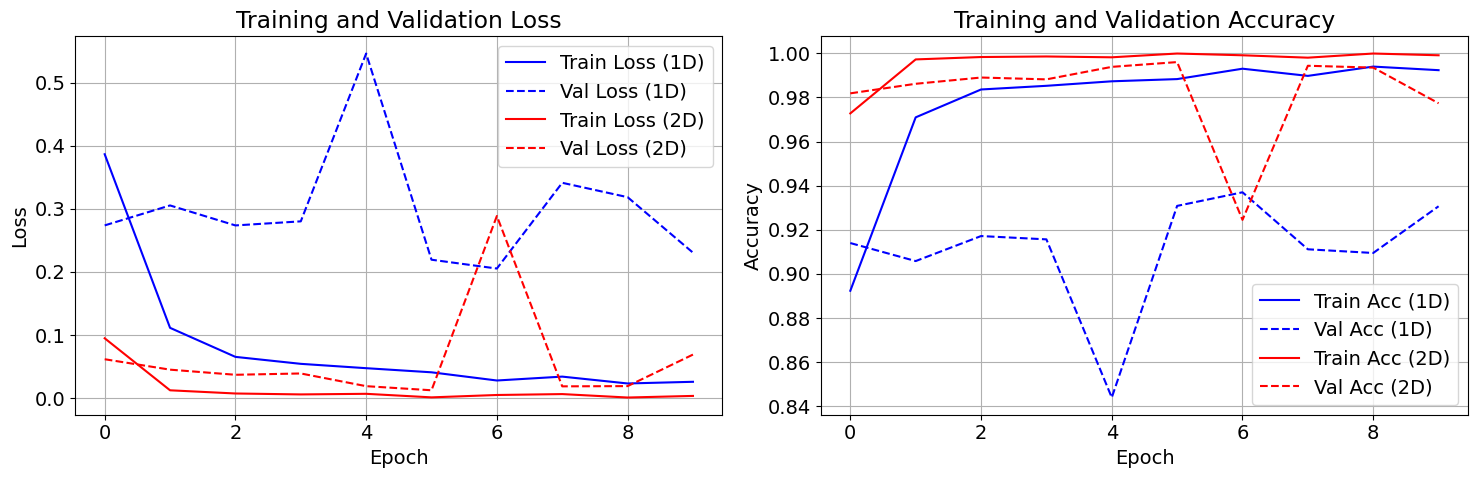

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses_1d, label='Train Loss (1D)', color='blue')
plt.plot(val_losses_1d, label='Val Loss (1D)', color='blue', linestyle='--')
plt.plot(train_losses_2d, label='Train Loss (2D)', color='red')
plt.plot(val_losses_2d, label='Val Loss (2D)', color='red', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accs_1d, label='Train Acc (1D)', color='blue')
plt.plot(val_accs_1d, label='Val Acc (1D)', color='blue', linestyle='--')
plt.plot(train_accs_2d, label='Train Acc (2D)', color='red')
plt.plot(val_accs_2d, label='Val Acc (2D)', color='red', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Выводы по результатам обучения базовых моделей

**1. Accuracy and Loss**

Модель ResNet2D (на спектрограммах) значительно превосходит модель ResNet1D (на waveform).

**Точность (Accuracy):**

2D Model.

Достигла очень высокой точности на валидации (97.73%). Кривая обучения быстро вышла на плато около 98-99% и оставалась стабильной.

1D Model

Показала заметно худший результат (93.07%). На графике видно, что точность "плавает" и не достигает такого же высокого уровня стабильности, как у 2D модели.

**Потери (Loss):**

2D Model

Потери на валидации очень низкие и стабильные (0.069), что говорит об отличной сходимости модели и отсутствии переобучения.

1D Model

Потери на валидации значительно выше (0.23) и демонстрируют сильную нестабильность (резкие скачки на эпохах 4 и 7), что может указывать на трудности с обучением или необходимость более тщательного подбора гиперпараметров.

Для задачи классификации цифр (AudioMNIST) в рамках данного эксперимента представление данных в виде спектрограмм (2D CNN) оказалось гораздо эффективнее, чем использование waveform (1D CNN).

## Task 2(2 points)

Train the Multi-Format Contrastive Learning of Audio Representations model (implemented during the seminar) until convergence. Plot the loss and accuracy curves to verify that the training process has stabilized.

### Модеь для MFC (Multi-Fromat Contrastive)

In [ ]:
class Net(nn.Module):
  def __init__(self, img_channels = 1, num_classes = 35):
    super(Net, self).__init__()
    ####################### ENCODER ###################################
    self.resnet_1D = ResNet1D(block, num_classes=num_classes)
    self.resnet_2D = ResNet2D(block2D, num_classes=num_classes)
    self.output = nn.Sequential(
        nn.Linear(512, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Linear(256, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Linear(256, 128)
    )
    ####################################################################

  def forward(self, input_spectogram, input_audio):
    """
        resnet2d and resnet1d output is [BS, 512, 1, 1]
        Output:
            - audio_emb, specs_emb used for contrastive loss
            - audio, spectograms used for Evaluation layer
            - output used for semi supervised - cross entropy
    """

    audio = self.resnet_1D(input_audio, return_features=True)
    audio = audio.squeeze()
    spectograms = self.resnet_2D(input_spectogram, return_features=True)
    spectograms = spectograms.squeeze()

    audio_emb = self.output(audio)
    specs_emb = self.output(spectograms)

    return audio_emb, specs_emb, audio, spectograms

class EvaluationHead(nn.Module):
  """
  Linear classifier head
  """
  def __init__(self, num_classes = 35):
    super(EvaluationHead, self).__init__()
    self.evaluation = nn.Sequential(nn.Linear(512, num_classes))

  def forward(self,x):
    return self.evaluation(x)

In [ ]:
def device_as(t1, t2):
  return t1.to(t2.device)

class ContrastiveLoss(nn.Module):
  def __init__(self, temperature=0.5):
    super().__init__()
    self.temperature = temperature

  def calc_similarity_batch(self, a, b):
    rep = torch.cat([a,b])
    return F.cosine_similarity(rep.unsqueeze(1), rep.unsqueeze(0), dim=2)

  def forward(self, proj_1, proj_2):
    batch_size = proj_1.shape[0]
    z_i = F.normalize(proj_1, p=2, dim=1)
    z_j = F.normalize(proj_2, p=2, dim=1)

    similarity_matrix = self.calc_similarity_batch(z_i, z_j)

    #######
    #aa#ab#
    #######
    #ba#bb#
    #######

    sim_ij = torch.diag(similarity_matrix, batch_size)
    sim_ji = torch.diag(similarity_matrix, -batch_size)

    positives = torch.cat([sim_ij, sim_ji])

    nominator = torch.exp(positives / self.temperature)

    mask = (~torch.eye(batch_size*2, batch_size*2).bool()).float()
    mask = device_as(mask, similarity_matrix)

    denominator = mask * torch.exp(similarity_matrix / self.temperature)
    all_losses = -torch.log(nominator / torch.sum(denominator, dim=1))
    loss = torch.sum(all_losses) / (2*batch_size)

    return loss

In [ ]:
def evaluationphase(model, val_loader, config, mel_transform, stft_trasform, device=None):

    model.eval()
    # Get dataloaders
    # Freeze the gradients for model1
    for param in model.parameters():
        param.requires_grad = False

    def train_head(model, trainloader, device):

        # Create model
        modelEvaluation = None
        modelEvaluation = EvaluationHead(num_classes = config.CLASSES).to(device)
        head_loss = None

        # Define the optimizer, the paper use
        optimizer = optim.Adam(modelEvaluation.parameters(), lr=config.LR)

        criterion = torch.nn.CrossEntropyLoss()

        for epoch in range(config.EVAL_EPOCHS):
            progress_bar = tqdm(total=len(trainloader), unit='step', leave=False)
            losses = []
            for audio,labels in trainloader:
                optimizer.zero_grad()
                audio = audio.to(device)
                # Create augmentation and spectograms!
                spectograms,audios = createModelInput(
                    audio,
                    mel_transform,
                    stft_trasform,
                    augmentation=False,
                    device=device)

                labels_cat = torch.cat([labels, labels], dim = 0).to(device)

                # Use frozen encoder
                with torch.no_grad():
                  _, _, frozen_audio, frozen_spects = model(spectograms, audios)

                inputs = torch.cat([frozen_audio, frozen_spects], dim = 0)
                outputs = modelEvaluation(inputs)
                loss = criterion(outputs, labels_cat)

                # Calculate loss and backward
                loss.backward()
                optimizer.step()

                losses.append(loss.item())

                #progress bar stuff
                head_loss = np.mean(losses)
                progress_bar.set_description(f"Head tuning epoch {epoch+1}/{config.EVAL_EPOCHS}")
                progress_bar.set_postfix(loss=head_loss)  # Update the loss value
                progress_bar.update(1)

            # end for batch
        return modelEvaluation, head_loss

    def evaluation(model, model_eval, dataloader, device):
      model_eval.eval()
      progress_bar = tqdm(total=len(dataloader), unit='step')
      total = 0
      correct = 0
      losses = []
      criterion = torch.nn.CrossEntropyLoss()
      with torch.no_grad():
        for i, (audio, labels) in enumerate(dataloader):
          audio = audio.to(device)
          spectograms, audios = createModelInput(
              audio,
              mel_transform,
              stft_trasform,
              augmentation=False,
              device=device
          )
          labels_cat = torch.cat([labels, labels], dim = 0).to(device)

          # Use frozen encoder
          _, _, frozen_audio, frozen_spects = model(spectograms, audios)
          inputs = torch.cat([frozen_audio, frozen_spects], dim = 0)
          outputs = model_eval(inputs)
          loss = criterion(outputs, labels_cat)
          losses.append(loss.item())
          _, predicated = torch.max(outputs.data, 1)
          total += labels_cat.size(0)

          correct += (predicated == labels_cat).sum().item()

          #progress bar stuff
          progress_bar.set_description(f"Evaluation {i+1}/{len(dataloader)}")
          progress_bar.update(1)
        # end for batch

      eval_loss = np.mean(losses)
      eval_accuracy = correct/total
      return eval_accuracy, eval_loss


    model_, train_head_loss = train_head(model, train_loader, device)
    eval_accuracy, eval_loss = evaluation(model, model_, val_loader, device)
    print(f"Train head result, train loss: {train_head_loss}, validation loss: {eval_loss}, validation accuracy: {eval_accuracy}")
    model.train()
    for param in model.parameters():
      param.requires_grad = True

    return eval_accuracy, eval_loss

### Тренировка модели

In [ ]:
def train(model, closs, optimizer, trainloader, valloader, config, mel_transform, stft_trasform, device=None):
  scaler = torch.amp.GradScaler()
  train_losses = []
  train_accs = []
  val_losses = []
  val_accs = []
  for epoch in range(config.EPOCHS):
    progress_bar = tqdm(total=len(trainloader), unit='step')
    epoch_losses = []
    clos_ = []
    epoch_correct = 0
    epoch_total = 0

    for audio, labels in trainloader:
      epoch_total = len(labels)
      optimizer.zero_grad()

      audio = audio.to(device)

      # Create augmentation and spectograms!
      spectograms, audios = createModelInput(
          audio,
          mel_transform,
          None,
          augmentation=True,
          device=device
      )

      with torch.amp.autocast(device_type=str(device)):
        audio_emb, spect_emb, _, _ = model(spectograms, audios)
        loss = closs(audio_emb, spect_emb)
        clos_.append(loss.item())

      # Calculate loss and backward
      scaler.scale(loss).backward()
      scaler.step(optimizer)
      scaler.update()

      #progress bar stuff
      progress_bar.set_description(f"Epoch {epoch+1}/{config.EPOCHS}")
      progress_bar.set_postfix(loss=loss.item())  # Update the loss value
      progress_bar.update(1)

      # save loss and accuracy to statistics
      epoch_losses.append(loss.item())

    # end for batch
    train_losses.append(np.mean(epoch_losses))
    train_accs.append(epoch_correct / epoch_total)

    if epoch%2 == 0:
      torch.save(model.state_dict(), f"models/model_{config.MODEL_TITLE}.pt")

    if epoch%2 == 0 or epoch == config.EPOCHS-1:
      # EVALUATION HEAD
      eval_accuracy, eval_loss = evaluationphase(
          model,
          valloader,
          config,
          mel_transform,
          stft_trasform,
          device=device
      )
      val_losses.append(eval_loss)
      val_accs.append(eval_accuracy)

  return train_losses, train_accs, val_losses, val_accs

In [ ]:
# Configuration
hyperparameters = {
    'LR': 3e-4,
    'WEIGHT_DECAY': 1e-6,
    'B1': 0.9,
    'B2': 0.999,
    'EPOCHS': 5,
    'BATCH_SIZE': 128,
    'IMG_CHANNEL': 1,
    'CLASSES': 10,
    'EVAL_BATCH': 128,
    'EVAL_EPOCHS': 1,
    'MODEL_TITLE': 'contrastive'
}

config = DictConfig(hyperparameters)

# Initialize model and optimizer
model = Net(img_channels=config.IMG_CHANNEL, num_classes=config.CLASSES).to(device)
closs = ContrastiveLoss()
mel_transform = LogMelSpectrogram(
    sample_rate=16000,
    n_fft=2048,
    hop_length=128,
    n_mels=128,
    f_min=40,
    f_max=8000
).to(device)

optimizer = optim.Adam(
    model.parameters(),
    lr=config.LR,
    betas=(config.B1, config.B2),
    weight_decay=config.WEIGHT_DECAY
)

# Create dataloaders
train_loader = DataLoader(train_ds, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=collate)
val_loader = DataLoader(valid_ds, batch_size=config.EVAL_BATCH, shuffle=False, collate_fn=collate)

# Train the model
train_losses, train_accuracies, val_losses, val_accuracies = train(
    model,
    closs,
    optimizer,
    train_loader,
    val_loader,
    config,
    mel_transform,
    None,
    device=device
)

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/47 [00:00<?, ?step/s]

Train head result, train loss: 1.6892682009554925, validation loss: 1.4418125330133642, validation accuracy: 0.5511666666666667


  0%|          | 0/188 [00:00<?, ?step/s]

...

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/47 [00:00<?, ?step/s]

Train head result, train loss: 1.629445401277948, validation loss: 1.3419855173597945, validation accuracy: 0.60525


In [ ]:
# Save best model
torch.save(model.state_dict(), 'contrastive_model.pth')
print("\nModel saved!")

torch.save({
    'epoch': config.EPOCHS,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_accuracies': train_accuracies,
    'val_accuracies': val_accuracies,
}, 'contrastive_model_checkpoint.pth')

print("\nModel checkpoint saved!")


Model saved!

Model checkpoint saved!


### Результат обучения

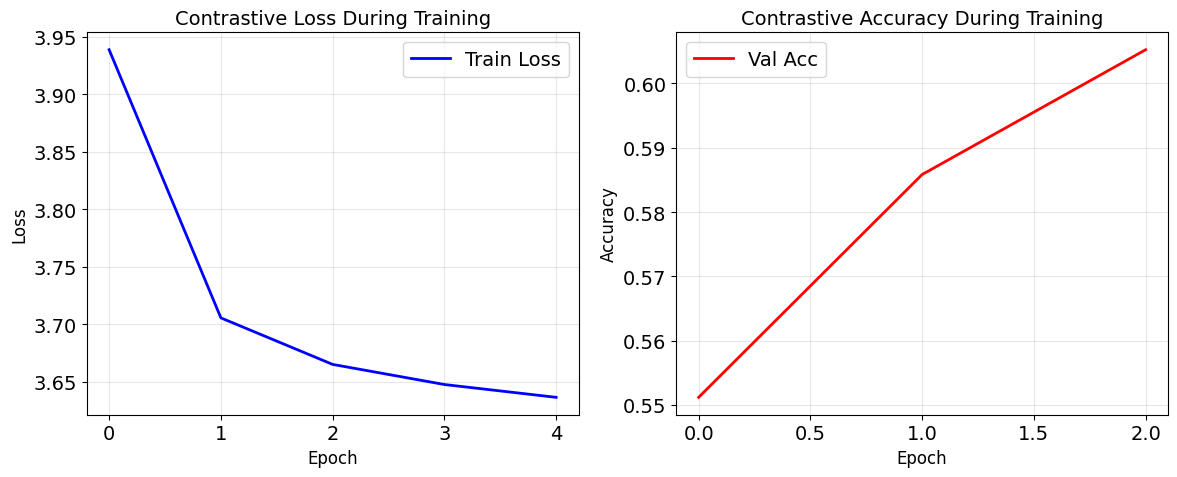


=== Training Convergence Analysis ===
Final Train Loss: 3.6366
Final Val Loss: 1.3420
Final Train Accuracy: 0.0000
Final Val Accuracy: 0.6052


In [ ]:
# Plot Loss Curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, 'b-', label='Train Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Contrastive Loss During Training', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, 'r-', label='Val Acc', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Contrastive Accuracy During Training', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print convergence information
print(f"\n=== Training Convergence Analysis ===")
print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Final Val Loss: {val_losses[-1]:.4f}")
print(f"Final Train Accuracy: {train_accuracies[-1]:.4f}")
print(f"Final Val Accuracy: {val_accuracies[-1]:.4f}")

1. Главная ошибка: .squeeze() в forward

audio = audio.squeeze()
spectograms = spectograms.squeeze()

Проблема
Если batch_size = 1, то:  [1, 512, 1] → squeeze → [512]

➡️ Ты теряешь batch dimension

➡️ Дальше Linear ожидает [B, 512], а получает [512]

✅ Исправление

Используй:
```
audio = audio.squeeze(-1)
spectograms = spectograms.squeeze(-1)
```
или лучше:
```
audio = audio.view(audio.size(0), -1)
spectograms = spectograms.view(spectograms.size(0), -1)
```
2. Неправильная форма входа в ResNet1D

ResNet1D ожидает: [B, 1, T], а из collate дается: [B, T]

Итог: Conv1d получает неправильную размерность

✅ Исправление

Перед моделью:
```
audio = audio.unsqueeze(1)  # [B, 1, T]
```
Проверьте createModelInput — скорее всего ошибка там.

3. Ошибка в Contrastive Loss (маска)
```
mask = (~torch.eye(batch_size*2, batch_size*2).bool()).float()
```
Проблема:
Вы НЕ убираете позитивные пары из знаменателя.
В SimCLR нужно:
* убрать диагональ
* убрать соответствующую пару (i, j)

✅ Правильнее:
```
mask = torch.ones((2*batch_size, 2*batch_size), device=similarity_matrix.device)
mask.fill_diagonal_(0)
```
(но это всё равно упрощённый вариант — у Вас сейчас loss немного “грязный”)

4. Очень странный момент в training loop:
```
epoch_total = len(labels)
```
Проблема: Это перезаписывается каждый батч → остаётся только последний.

Нужно:
```
epoch_total += len(labels)
```
НО:
```
epoch_correct = 0
```
Вы его вообще не считаете → accuracy всегда 0

5. GradScaler + device bug
```
with torch.amp.autocast(device_type=str(device)):
```
Проблема: device = "cuda:0" → autocast ждёт "cuda"

Исправление:
```
with torch.amp.autocast(device_type="cuda"):
```
6. Evaluation: утечка train_loader
```
model_, train_head_loss = train_head(model, train_loader, device)
```
Проблема:
`train_loader` не передаётся в функцию → берётся из глобальной области

Лучше:
```
def evaluationphase(..., train_loader, ...):
```
7. Дублирование данных
```
labels_cat = torch.cat([labels, labels], dim=0)
inputs = torch.cat([frozen_audio, frozen_spects], dim=0)
```
Это нормально, но если audio и spectrogram плохо синхронизированы → модель не учится

8. Потенциальная проблема: один и тот же MLP для двух модальностей
```
audio_emb = self.output(audio)
specs_emb = self.output(spectograms)
```
Это допустимо (SimCLR-style), но иногда лучше:
```
self.audio_head
self.spec_head
```
Минимальный чек-лист исправлений

Вот что нужно сделать в первую очередь:

✅ 1. fix squeeze
```
audio = audio.view(audio.size(0), -1)
spectograms = spectograms.view(spectograms.size(0), -1)
```

✅ 2. fix input shape
```
audio = audio.unsqueeze(1)
```
✅ 3. fix autocast
```
with torch.amp.autocast(device_type="cuda"):
```
✅ 4. убрать лишний pad_sequence
```
[w.squeeze(0) for w in wavs]
```
💡 Самая вероятная причина, если "не учится".
Если loss не падает, то почти всегда это:
👉 №1 кандидат:

❌ неправильная форма [B, T] вместо [B, 1, T]

👉 №2:

❌ .squeeze() убивает batch

👉 №3:

❌ contrastive loss реализован криво

## Task 3(4 points)

Replace the InfoNCE loss in Multi-Format Contrastive Learning of Audio Representations with a Non-Contrastive Learning method.
Train the model until convergence, then plot the loss and accuracy curves to check that training has stabilized.

You can try one of the following NCL methods:
- BYOL([paper](https://arxiv.org/pdf/2006.07733))
- SimSiam([paper](https://arxiv.org/pdf/2011.10566))
- Barlow Twins([paper](https://arxiv.org/pdf/2103.03230))
- VicReg([paper](https://arxiv.org/pdf/2105.04906))

Feel free to use a more recent Non-Contrastive approach if you prefer—just explain briefly why you chose it.


### Попробуем Barlow Twins
Для выполнения третьего задания мы заменим функцию потерь InfoNCE (контрастивное обучение) на метод Barlow Twins.

Есть уже некоторые реализации метода Barlow Twins на GitHub. Ими и будем вдохновляться.

### Функции потерь Barlow Twins

In [ ]:
def barlow_twins_loss(z1, z2, lambda_param=0.005):
  # Нормализация векторов
  z1_norm = (z1 - z1.mean(dim=0)) / z1.std(dim=0)
  z2_norm = (z2 - z2.mean(dim=0)) / z2.std(dim=0)

  # Матрица корреляции C_ij
  # C = (z1_norm.T @ z2_norm) / N
  N = z1.shape[0]
  c = torch.mm(z1_norm.T, z2_norm) / N

  # Loss = Sum((1 - C_ii)^2) + lambda * Sum(C_ij^2) for i != j
  on_diag = torch.diagonal(c).add_(-1).pow_(2).sum()

  off_diag = c.clone()
  off_diag.fill_diagonal_(0)
  off_diag = off_diag.pow_(2).sum()

  loss = on_diag + lambda_param * off_diag
  return loss

### Архитектура модели

In [ ]:
class ProjectionHead(nn.Module):
  """
  Projection head для метода Barlow Twins.
  """
  def __init__(self, input_dim, projection_dim=2048, hidden_dim=2048):
    super(ProjectionHead, self).__init__()
    self.projector = nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.BatchNorm1d(hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, projection_dim),
        nn.BatchNorm1d(projection_dim, affine=False)
    )

  def forward(self, x):
    # x shape: [Batch, Channels, Time] or [Batch, Channels, H, W]
    # Flatten
    if x.dim() > 2:
      x = torch.flatten(x, start_dim=1)
    return self.projector(x)

class MultiFormatModelBarlow(nn.Module):
  def __init__(self, encoder_1d, encoder_2d, projection_dim=2048):
    super(MultiFormatModelBarlow, self).__init__()
    self.encoder_1d = encoder_1d
    self.encoder_2d = encoder_2d

    input_dim = 512

    self.projector_1d = ProjectionHead(input_dim, projection_dim)
    self.projector_2d = ProjectionHead(input_dim, projection_dim)

  def forward(self, wav, spec):
    emb_1d = self.encoder_1d(wav, return_features=True)
    emb_2d = self.encoder_2d(spec, return_features=True)
    z_1d = self.projector_1d(emb_1d)
    z_2d = self.projector_2d(emb_2d)

    return z_1d, z_2d

### Тренировка модели

In [ ]:
def train_barlow_twins(model, optimizer, train_loader, val_loader, config, mel_transform, device):
  train_losses_bt = []
  val_accs_bt = []
  model.train()
  validation_acc = []

  scaler = torch.amp.GradScaler()

  for epoch in range(config.EPOCHS):
    model.train()
    epoch_loss = 0.0
    progress_bar = tqdm(total=len(train_loader), desc=f"Epoch {epoch+1}/{config.EPOCHS}")

    for audio, labels in train_loader:
      audio = audio.to(device)

      optimizer.zero_grad()

      # View 1: Первая аугментация
      spec_1, aug_wav_1 = createModelInput(
          audio,
          mel_transform,
          None,
          augmentation=True,
          device=device
      )
      # View 2: Другая аугментация
      spec_2, aug_wav_2 = createModelInput(
          audio,
          mel_transform,
          None,
          augmentation=True,
          device=device
      )

      with torch.amp.autocast(device_type=str(device)):
        # Forward
        z1, z2 = model(aug_wav_1, spec_2)
        emb_1d = model.encoder_1d(aug_wav_1, return_features=True)
        emb_2d = model.encoder_2d(spec_2, return_features=True)

        z1 = model.projector_1d(emb_1d)
        z2 = model.projector_2d(emb_2d)

        loss = barlow_twins_loss(z1, z2, lambda_param=config.LAMBDA_PARAM)

      scaler.scale(loss).backward()
      scaler.step(optimizer)
      scaler.update()

      epoch_loss += loss.item()
      progress_bar.update(1)

    avg_loss = epoch_loss / len(train_loader)
    train_losses_bt.append(avg_loss)
    progress_bar.set_postfix({"Loss": f"{avg_loss:.4f}"})
    #accuracy_bt = evaluate_barlow_twins(
    #    model,
    #    val_loader,
    #    device,
    #    num_classes=config.CLASSES
    #)
    #validation_acc.append(accuracy_bt)

    torch.cuda.synchronize()
    torch.cuda.empty_cache()

    progress_bar.close()

  return train_losses_bt

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")

device: cuda


In [ ]:
# Запуск обучения
# Гиперпараметры
hyperparameters_bt = {
    'LR': 1e-3,
    'WEIGHT_DECAY': 1e-6,
    'LAMBDA_PARAM': 0.005,
    'EPOCHS': 10,
    'BATCH_SIZE': 64,
    'EVAL_BATCH': 128,
    'CLASSES': 10
}
config_bt = DictConfig(hyperparameters_bt)

# Init dataloaders
train_loader = DataLoader(
    train_ds,
    batch_size=config_bt.BATCH_SIZE,
    shuffle=True,
    collate_fn=collate
)
val_loader  = DataLoader(
    valid_ds,
    batch_size=config_bt.EVAL_BATCH,
    shuffle=False,
    collate_fn=collate
)

# Create mel transform
mel_transform = LogMelSpectrogram(
    sample_rate=16000,
    n_fft=2048,
    hop_length=128,
    n_mels=128,
    f_min=40,
    f_max=8000,
    mel_scale="slaney").to(device)

# Инициализация энкодеров
encoder_1d = ResNet1D(block, num_classes=10).to(device)
encoder_2d = ResNet2D(block2D, num_classes=10).to(device)

model_bt = MultiFormatModelBarlow(encoder_1d, encoder_2d).to(device)

optimizer_bt = optim.Adam(
    model_bt.parameters(),
    lr=config_bt.LR,
    weight_decay=config_bt.WEIGHT_DECAY
)

train_losses_bt = train_barlow_twins(
    model_bt,
    optimizer_bt,
    train_loader,
    val_loader,
    config_bt,
    mel_transform,
    device=device
)

Epoch 1/10:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 2/10:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 3/10:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 4/10:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 5/10:   0%|          | 0/375 [00:00<?, ?it/s]

...

Epoch 7/10:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 8/10:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 9/10:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 10/10:   0%|          | 0/375 [00:00<?, ?it/s]

NameError: name 'accuracy_bt' is not defined

В коде функции train_barlow_twins в самом конце не удалил строку с несуществующим параметром "accuracy_bt". Из-за этого произошла ошибка. GPU ресурсов уже не хватило, чтобы повторно запустить train_barlow_twins.

Поэтому сами значения loss функции взял из тех, что были записаны в progress bars.

In [ ]:
# Пояснение к этому действию выше.
train_losses_bt = [
    1707.0921, 1413.5448, 1290.4973, 1202.3426, 1144.7200, 1128.0302, 1082.6817, 1038.6726, 970.4318, 903.4794
]

In [ ]:
# Сохраним модель
torch.save(model_bt.state_dict(), 'barlow_twins_model.pth')
print("\nModel saved!")


Model saved!


### Визуализация результатов обучения

<Figure size 1000x600 with 0 Axes>

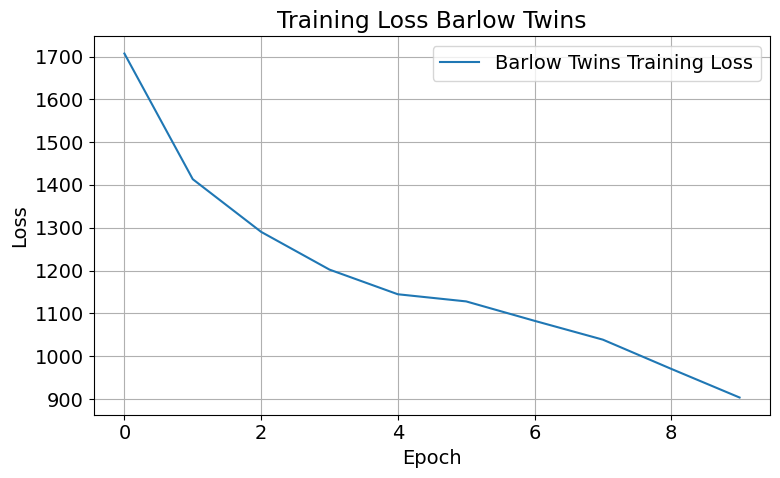

In [ ]:
plt.figure(figsize=(10, 6))

plt.show()

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses_bt, label='Barlow Twins Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Barlow Twins')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

1. Критичная ошибка: Вы не используете две аугментации корректно. Вы создаёте
```
spec_1, aug_wav_1 = ...
spec_2, aug_wav_2 = ...
```
Но дальше:
```
z1, z2 = model(aug_wav_1, spec_2)
```

То есть:
* z1 ← из aug_wav_1
* z2 ← из другого view, но другой модальности

💥 Проблема: Barlow Twins предполагает два представления ОДНОГО объекта через разные аугментации. А у Вас:
* 1D view → из одной аугментации
* 2D view → из другой аугментации

2. Дублирование forward (лишние вычисления)
```
z1, z2 = model(...)
emb_1d = model.encoder_1d(...)
emb_2d = model.encoder_2d(...)
z1 = model.projector_1d(emb_1d)
z2 = model.projector_2d(emb_2d)
```
Это дважды гоняет энкодеры, увеличивает время ×2, может давать несогласованные результаты (dropout / BN).
Нужно оставить один вариант:
```
z1, z2 = model(...)
```
3. Неправильное использование multi-modal Barlow Twins
Сейчас Вы фактически делаете:
```
z1 = projector_1d(encoder_1d(wav))
z2 = projector_2d(encoder_2d(spec))
loss(z1, z2)
```
Проблема: Вы заставляете разные модальности совпадать напрямую
- это слишком жёсткое ограничение

Последствия:
* collapse или плохие представления
* потеря модально-специфической информации

Обычно делают:

Вариант A (правильный):
* BT внутри модальности:
* wav ↔ wav
* spec ↔ spec
* дополнительный cross-modal loss
Вариант B:
* общий encoder (или shared head)

4. Фиксированный input_dim = 512
Проблема:
* если encoder меняется → всё ломается
* нет проверки соответствия размерности

Лучше:
* input_dim = encoder_output_dim
* или вычислять динамически.

5. BatchNorm + маленькие батчи.
Barlow Twins очень чувствителен к batch size.
Если batch < ~256, то плохая оценка статистик и шум в корреляции.

Решения: увеличить batch или использовать LayerNorm, GroupNorm

6. Нестабильная нормализация z1.std(dim=0).
Возможные проблемы:
* деление на 0
* NaN при маленькой дисперсии

Лучше:
```
eps = 1e-9
z1_norm = (z1 - z1.mean(0)) / (z1.std(0) + eps)
```
7. Нет симметрии (важно для BT). 
Классический Barlow Twins: `loss(z1, z2) == loss(z2, z1)`

У Вас — ок, но архитектурно разные projector'ы → асимметрия.
Лучше: shared projector или weight tying.

8. Отсутствует stop-gradient (опционально).
BT не требует, но в multi-modal setup иногда помогает стабилизация.

9. Возможный collapse. BT защищён от collapse, но у Вас:
* разные модальности
* разные projector'ы
риск снова появляется

10. Нет balancing между on/off diagonal
`lambda_param = 0.005`
Это значение сильно зависит от dim и batch size

Иногда нужно: 0.01; 0.1

---

Главный вывод

Самая большая проблема — логическая ошибка постановки задачи. Вы смешали:
* multi-view (Barlow Twins)
* multi-modal alignment

Но реализовали это как: "сделай wav embedding = spectrogram embedding". Это слишком жёстко и неправильно.

Как исправить (минимальный фикс): два view
```
z1_wav, z1_spec = model(aug_wav_1, spec_1)
z2_wav, z2_spec = model(aug_wav_2, spec_2)
```
```
loss = (
    barlow_twins_loss(z1_wav, z2_wav) +
    barlow_twins_loss(z1_spec, z2_spec)
)
```
И отдельно (опционально):
```
cross_loss = mse(z1_wav, z1_spec)
```
---

Если кратко, Топ-5 проблем:
* Перемешаны аугментации (главная ошибка)
* Дублирование forward
* Неправильная multi-modal постановка
* BatchNorm + маленький batch
* Жёсткое выравнивание разных модальностей

## Task 4(2 points)

Evaluate and compare three training setups on the validation subset:

1. Supervised training

2. InfoNCE (contrastive learning)

3. Non-Contrastive Learning (NCL)

Use either the 2D or 1D encoder—or combine their embeddings.
Identify which setup performs best and explain why it outperforms the others.

### Функция eval для модели по методу Barlow Twins

In [ ]:
class EvaluationHead2(nn.Module):
  """
  Linear classifier head
  """
  def __init__(self, input_dim, num_classes = 35):
    super(EvaluationHead2, self).__init__()
    self.evaluation = nn.Sequential(
        nn.Linear(input_dim, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )

  def forward(self,x):
    return self.evaluation(x)

In [ ]:
encoder_1d = ResNet1D(block, num_classes=10).to(device)
encoder_2d = ResNet2D(block2D, num_classes=10).to(device)

model_bt = MultiFormatModelBarlow(encoder_1d, encoder_2d).to(device)

# 2. Загрузите сохраненные веса
model_bt.load_state_dict(torch.load('barlow_twins_model.pth'))

In [ ]:
def evaluate_barlow_twins(model, dataloader, device, num_classes=10):
    # Заморозим энкодеры
    model.encoder_1d.eval()
    model.encoder_2d.eval()
    model.projector_1d.eval()
    model.projector_2d.eval()

    for param in model.parameters():
      param.requires_grad = False

    eval_head = EvaluationHead2(4096, num_classes=num_classes).to(device)
    eval_head.train() # Голова в train mode

    optimizer = optim.Adam(eval_head.parameters(), lr=1e-3, weight_decay=0)
    criterion = nn.CrossEntropyLoss()

    model.eval()
    eval_head.train()

    total_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(dataloader, desc="Linear Eval")

    with torch.no_grad():
      pass

    for wav, labels in progress_bar:
        wav = wav.to(device)
        if wav.dim() == 2:
          wav = wav.unsqueeze(1)

        labels = labels.to(device)
        wav_for_spec = wav.squeeze(1)
        spec = mel_transform(wav_for_spec)

        with torch.no_grad():
          emb_1d = model.encoder_1d(wav, return_features=True)
          emb_2d = model.encoder_2d(spec, return_features=True)
          z_1d = model.projector_1d(emb_1d)
          z_2d = model.projector_2d(emb_2d)
          combined_z = torch.cat((z_1d, z_2d), dim=1)

        logits = eval_head(combined_z)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(logits.data, 1)
        total += len(labels)
        correct += (predicted == labels).sum().item()

        total_loss += loss.item()
        progress_bar.set_postfix({'loss': total_loss / total, 'acc': correct / total})

    accuracy = correct / total
    return accuracy

In [ ]:
accuracy_bt = evaluate_barlow_twins(model_bt, val_loader, device, 10)

Linear Eval:   0%|          | 0/47 [00:00<?, ?it/s]

In [ ]:
print(f"MFC learning with Barlow Twins Non-Contrastive method, Validation Accuracy: {accuracy_bt:.4f}")

MFC learning with Barlow Twins Non-Contrastive method, Validation Accuracy: 0.4863


### Accuracy для всех методов (моделей)
*   Waveform (1D) Model, Validation Accuracy: 0.9307
*   Spectrogram (2D) Model, Validation Accuracy: 0.9773
*   MFC learning with Contrastive method, Validation Accuracy: 0.6052
*   MFC learning with Barlow Twins Non-Contrastive method, Validation Accuracy: 0.4863

### Выводы

Waveform (1D) и Spectrogram (2D) модели показали отличные результаты - 93% и 97.7%.

2D модель работает лучше, что ожидаемо. Спектрограммы содержат больше структурированной информации.

Contrastive и Non-Contrastive методы в моей реализации показали слабее результаты: 60.5% и 48.6%.

Результат 48.6% говорит о том, что модель MFCL NC Barlow Twins, не выучила ничего полезного для классификации.

Возможные причины, по которым модели InfoNCE и Barlow Twins не обучились должным образом (мои предположения):
- недостаточное количество эпох для обучения,
- есть ошибки в коде вычисления loss функции, которые заметил уже после обучения и исчерпания ресурсов GPU,
- для Barlow Twins я использовал wav для первого encoder и спектрограмму для второго encoder, а нужно подавать на вход в encoder's одинаковые форматы, но с аугментациями.